# **Monte Carlo Approximation:**
=========================================================================

- **DEFINITION:**
- Let $X_1$, $X_2$, $X_3$ be i.i.d. integral real valued random variables on the same probability space $(\Omega, P)$ with $\mu = E^P(X_i)$ for i = 1, 2, 3, ..., then we call:

$$
\frac{1}{n} \sum_{i=1}^{n} X_i 
$$

a Monte Carlo approximation of the expectation $\mu$ and 

$$
\frac{1}{n} \sum_{i=1}^{n} X_i(w) 
$$

- $w$ is an outcome in $\Omega$, so X_i(w) is a value that takes $X$ at $w$

a Monte Carlo sampling or simulation approximating the expectation $\mu$



## **CONVERGENCE RESULT(THE STRONG LAW OF NUMBERS)**
- **REMEMBER THE STRONG LAW OF NUMBERS**
- Let $X_1$, $X_2$, $X_3$ be i.i.d. integral real valued random variables on the same probability space $(\Omega, P)$ with 

$$
\mu = E^P(X_i), \space for \space \space i = 1, 2, 3, ...
$$

then 

$$
P({\lim_{n \to \infty} \frac{1}{n} \sum_{i=1}^{n} X_i =\mu}) = 1
$$

that is
$$
\frac{1}{n} \sum_{i=1}^n X_i \space \space \to \mu \space almost \space surely \space as \space n \to \infty
$$


> The probability that the sample mean be equal to the population mean is 1, as n approaches infinity. 

- **REMARK:**
- There are generalizations, so called **ergodic theorems**, where the *requirement of i.i.d. is relarex*. In the context of **ergodic theorems** $\lim_{n \to \infty} \frac{1}{n} \sum_{i=1}^{n} X_i$ is called the time average and $\mu = E^P$ is called the space average. 
- So, Ergodic theory now states that under certain conditions the time average is equal to the space average, almost surely. 
- So, we know that times average converges, **do we have a convergence rate?**



## **CENTRAL LIMIT THEOREM**
- Let $X_1$, $X_2$, $X_3$ be i.i.d. integral real valued random variables on the same probability space $(\Omega, P)$ with 

$$
\mu = E^P(X_i), \space for \space \space i = 1, 2, 3, ...
$$

$$
\sigma^2 = E^P((X_i - \mu)^2)
$$

- for i = 1, 2, 3, ..., then for all a<b

$$
\lim_{n \to \infty}P[a \leq { \frac{1}{\sqrt{n} \cdot \sigma} \sum_{i=1}^{n} (X_i - \mu) \leq b}] = \phi(b) - \phi(a)
$$
-  **only if a < b**

- where $\phi(x):= \frac{1}{\sqrt{2 \cdot \pi}} \int_{-\infty}^{x} e^{-\frac{1}{2}y^2} dy$ is the `cummulative normal ditribution function. `   

- **REWRITING THE EXPRESSION:**
- $\frac{a\cdot \sigma}{\sqrt{n}} \leq { \frac{1}{n}} \sum_{i=1}^{n} (X_i - \mu) \leq \frac{b\cdot \sigma}{\sqrt{n}}$

> When n tends to infinity the prob of the expression $\frac{1}{\sqrt{n} \cdot \sigma } \sum_{i=1}^{n} (X_i - \mu)$ lies between a and b is the cdf's b minus cdf's a.


> In the *rewriting expression* we can see that the difference between the MC approximation and my true expectation lis with a certain probability in an interval $(\frac{a\cdot \sigma}{\sqrt{n}}, \frac{b\cdot \sigma}{\sqrt{n}})$ that becomes smaller and smaller as n increases.

> Problem: We continue with the problem that it holds only in probability, so we have to find a way to make it holds almost surely. Furthermore, a big problem is that is holds in the limit, so we have to find a way to make it holds for all n. However, the limit can be fixed using the *Chebyshev inequality*

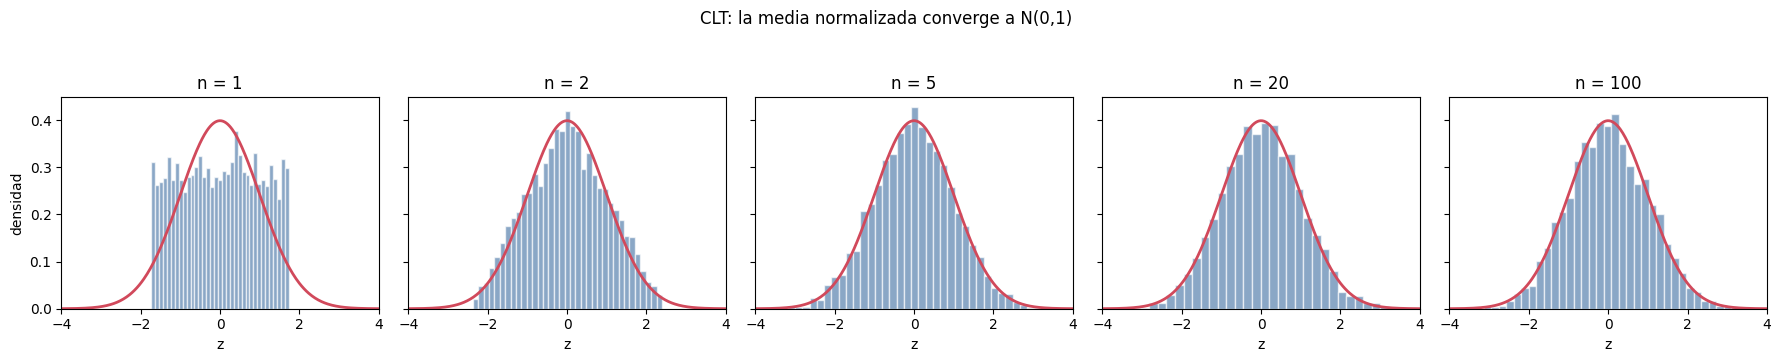

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi

rng = np.random.default_rng(1234)

def normal_pdf(x):
    return np.exp(-0.5 * x**2) / sqrt(2 * pi)

# Central Limit Theorem: normalized sample means look increasingly normal
sample_size = 4000
n_values = [1, 2, 5, 20, 100]
mu = 0.5
sigma = np.sqrt(1.0 / 12.0)  # Uniform(0,1)

fig, axes = plt.subplots(1, len(n_values), figsize=(18, 3.4), sharey=True)
for ax, n in zip(axes, n_values):
    samples = rng.uniform(0.0, 1.0, size=(sample_size, n))
    standardized = np.sqrt(n) * (samples.mean(axis=1) - mu) / sigma
    x = np.linspace(-4, 4, 400)
    ax.hist(standardized, bins=35, density=True, alpha=0.65, color="#4C78A8", edgecolor="white")
    ax.plot(x, normal_pdf(x), color="#D1495B", linewidth=2)
    ax.set_title(f"n = {n}")
    ax.set_xlim(-4, 4)

axes[0].set_ylabel("densidad")
for ax in axes:
    ax.set_xlabel("z")
fig.suptitle("CLT: la media normalizada converge a N(0,1)", y=1.05)
fig.tight_layout()
plt.show()

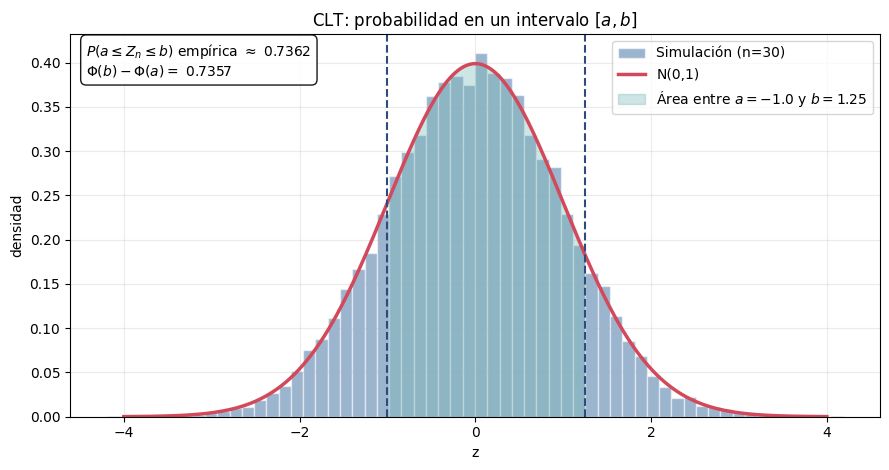

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt, pi

def normal_pdf(x):
    return np.exp(-0.5 * x**2) / sqrt(2 * pi)

def normal_cdf(x):
    x = np.asarray(x)
    return 0.5 * (1 + np.vectorize(erf)(x / np.sqrt(2)))

# CLT interval illustration for X_i ~ Uniform(0,1)
a, b = -1.0, 1.25
n = 30
replications = 20000

samples = rng.uniform(0.0, 1.0, size=(replications, n))
standardized = np.sqrt(n) * (samples.mean(axis=1) - mu) / sigma

empirical_prob = np.mean((standardized >= a) & (standardized <= b))
normal_prob = normal_cdf(b) - normal_cdf(a)

x = np.linspace(-4, 4, 500)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(standardized, bins=60, density=True, alpha=0.55, color="#4C78A8", edgecolor="white", label=f"Simulación (n={n})")
ax.plot(x, normal_pdf(x), color="#D1495B", linewidth=2.5, label="N(0,1)")
mask = (x >= a) & (x <= b)
ax.fill_between(x[mask], normal_pdf(x[mask]), color="#72B7B2", alpha=0.35, label=fr"Área entre $a={a}$ y $b={b}$")
ax.axvline(a, color="#2F4B7C", linestyle="--", linewidth=1.5)
ax.axvline(b, color="#2F4B7C", linestyle="--", linewidth=1.5)
ax.set_xlabel("z")
ax.set_ylabel("densidad")
ax.set_title("CLT: probabilidad en un intervalo $[a,b]$")
ax.text(
    0.02,
    0.98,
    fr"$P(a \leq Z_n \leq b)$ empírica $\approx$ {empirical_prob:.4f}" "\n"
    fr"$\Phi(b)-\Phi(a) =$ {normal_prob:.4f}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9),
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### **CHEBYSHEV INEQUALITY**
- Let $X \in L^2(\omega, \mathbb{R})$ denote a random variable, meaning that $\mathbb{E}[X^2] < \infty$.
- Let $\mu := \mathbb{E}[X]$ and $\mathrm{Var}(X) := \mathbb{E}[(X-\mu)^2]$.
- Let $\epsilon > 0$ be an arbitrary tolerance level. Then:

$$
P(|X - \mathbb{E}[X]| \geq \epsilon) \leq \frac{\mathrm{Var}(X)}{\epsilon^2}.
$$

- **PROOF:**
$$
\mathrm{Var}(X) = \int_{-\infty}^{\infty} (x - \mathbb{E}[X])^2 \phi(x)\,dx \geq \int_{|x-\mathbb{E}[X]| \geq \epsilon} (x - \mathbb{E}[X])^2 \phi(x)\,dx
$$

$$
\geq \int_{|x-\mathbb{E}[X]| \geq \epsilon} \epsilon^2 \phi(x)\,dx = \epsilon^2 P(|X - \mathbb{E}[X]| \geq \epsilon).
$$

- **GENERALIZATION:**
- Let $1 < q < 2$ and assume $\mathbb{E}[|X-\mathbb{E}[X]|^q] < \infty$.
- Here, $q$ is the order of the moment we use. It is not a probability; it is the exponent in the $q$-th moment.

$$
P(|X - \mathbb{E}[X]| \geq \epsilon) \leq \frac{\mathbb{E}[|X - \mathbb{E}[X]|^q]}{\epsilon^q}.
$$

> The probability that the deviation from the mean is greater than $\epsilon$ is less than or equal to the variance divided by $\epsilon^2$.

> We can use this as follows: if $X = \frac{1}{n} \sum_{i=1}^{n} X_i$, then the expectation is
$$
\mathbb{E}[X] = \frac{1}{n} \sum_{i=1}^{n} \mathbb{E}[X_i] = \mu.
$$

- If $X_i$ are i.i.d. with $\mathrm{Var}(X_i)=\sigma^2$, then
$$
\mathrm{Var}(X) = \mathrm{Var}\left(\frac{1}{n} \sum_{i=1}^{n} X_i\right) = \frac{1}{n^2} \sum_{i=1}^{n} \mathrm{Var}(X_i) = \frac{\sigma^2}{n}.
$$

- `SO THIS IS THE ERROR OF THE MONTE CARLO APPROXIMATION`

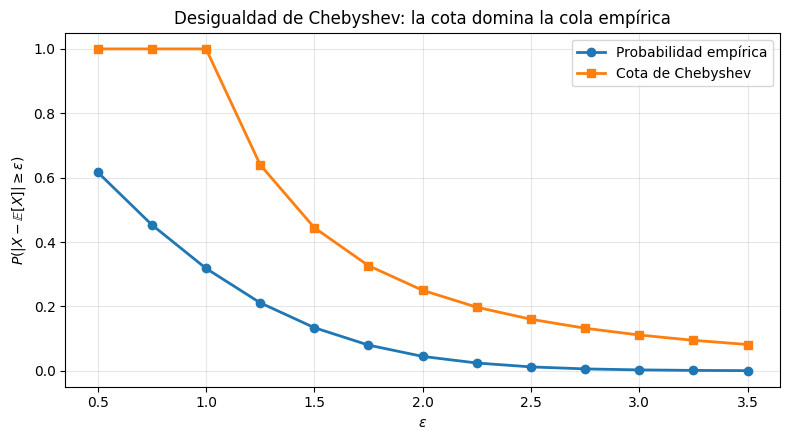

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(4321)

# Chebyshev inequality: empirical tail probability vs theoretical bound
x = rng.normal(loc=0.0, scale=1.0, size=200000)
eps_values = np.linspace(0.5, 3.5, 13)
empirical_tail = np.array([np.mean(np.abs(x) >= eps) for eps in eps_values])
chebyshev_bound = np.minimum(1.0, 1.0 / eps_values**2)

plt.figure(figsize=(8, 4.5))
plt.plot(eps_values, empirical_tail, marker="o", linewidth=2, label="Probabilidad empírica")
plt.plot(eps_values, chebyshev_bound, marker="s", linewidth=2, label="Cota de Chebyshev")
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$P(|X-\mathbb{E}[X]| \geq \epsilon)$")
plt.title("Desigualdad de Chebyshev: la cota domina la cola empírica")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### **MONTE CARLO CONVERGENCE RATIO:**
- Let $X_1$, $X_2$, $X_3$ be i.i.d. integral real valued random variables on the same probability space $(\Omega, P)$ with 

$$
\mu = E^P(X_i), \space for \space \space i = 1, 2, 3, ...
$$

$$
\sigma^2 = E^P((X_i - \mu)^2)
$$

- for i = 1, 2, 3, ..., Then for any $\epsilon > 0$ and fixed $n \geq 1 $

$$
P(|\frac{1}{n} \sum_{i=1}^{n} X_i - \mu| \geq \epsilon) \leq \frac{\sigma^2}{n \cdot \epsilon^2}
$$

- and for $\delta> 0$
$$
P[|\frac{1}{n} \sum_{i=1}^{n} X_i - \mu| < \frac{\sigma}{\delta^{1/2} \cdot n^{1/2}})] \geq 1 - \delta
$$ 

> The probability that the error ($|\frac{1}{n} \sum_{i=1}^{n} X_i - \mu|$) be less than $\frac{\sigma}{\delta^{1/2} \cdot n^{1/2}}$ is greater o equal than 1 - $\delta$.

> No limits going to infinity involved here, and this holds for fixed n. We only have the result *in probability.*

> So the convergence rate is $\frac{1}{\sqrt{n}}$

>  $\sigma$ is the variance of the f(x)

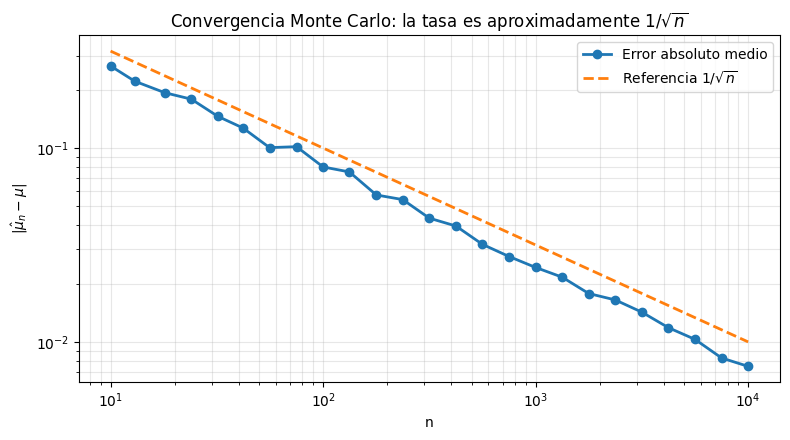

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(9876)

# Monte Carlo convergence rate: mean absolute error decays like 1/sqrt(n)
true_mean = 1.0  # Exp(1)
sigma = 1.0
n_values = np.unique(np.round(np.logspace(1, 4, 25)).astype(int))
replications = 200
mean_abs_error = []
reference_curve = sigma / np.sqrt(n_values)

for n in n_values:
    estimates = rng.exponential(scale=1.0, size=(replications, n)).mean(axis=1)
    mean_abs_error.append(np.mean(np.abs(estimates - true_mean)))

mean_abs_error = np.array(mean_abs_error)

plt.figure(figsize=(8, 4.5))
plt.loglog(n_values, mean_abs_error, marker="o", linewidth=2, label="Error absoluto medio")
plt.loglog(n_values, reference_curve, linestyle="--", linewidth=2, label=r"Referencia $1/\sqrt{n}$")
plt.xlabel("n")
plt.ylabel(r"$|\hat\mu_n - \mu|$")
plt.title(r"Convergencia Monte Carlo: la tasa es aproximadamente $1/\sqrt{n}$")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()